# Simple Linear Regression

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np

Downloading the data

In [1]:
!curl https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv -o FuelConsumptionCo2.csv

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
  0      0   0      0   0      0      0      0           00:01              0
  0      0   0      0   0      0      0      0           00:02              0
 32  72629  32  23867   0      0   7375      0   00:09   00:03   00:06   7384
 55  72629  55  40652   0      0   9359      0   00:07   00:04   00:03   9366
100  72629 100  72629   0      0  13599      0   00:05   00:05           9366
100  72629 100  72629   0      0  13598      0   00:05   00:05           9366
100  72629 100  72629   0      0  13597      0   00:05   00:05           9366


Now we read the data to understand the basic structure

In [4]:
df = pd.read_csv("FuelConsumptionCo2.csv")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


Lets have a solid grasp of our data using the describe method

In [5]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


Now we select some features and explore more

In [6]:
cdf = df[["ENGINESIZE", "CYLINDERS", "FUELCONSUMPTION_COMB", "CO2EMISSIONS"]]
cdf.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244


we will plot each of the features to visualize the data better

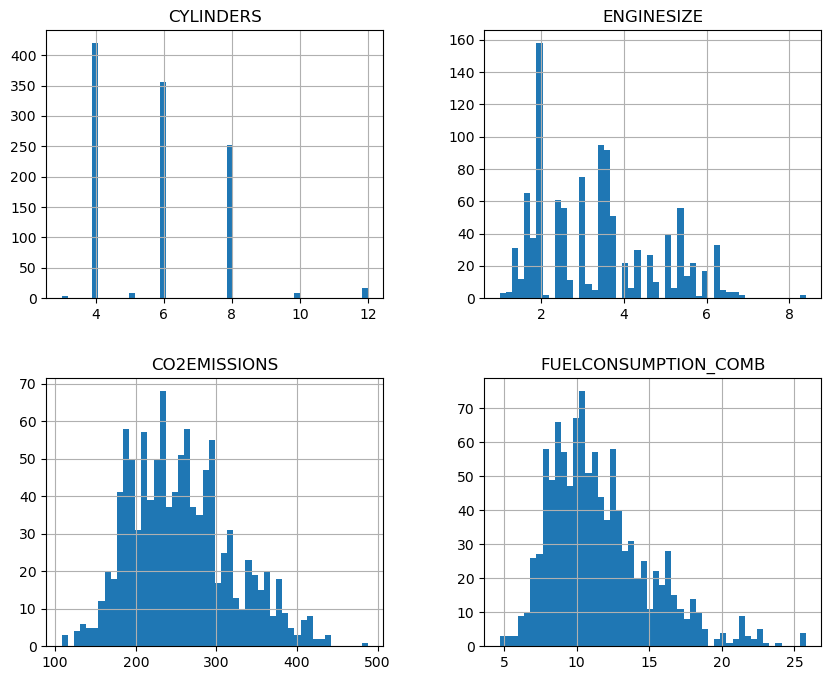

In [8]:
viz = cdf[["CYLINDERS", "ENGINESIZE", "CO2EMISSIONS", "FUELCONSUMPTION_COMB"]]
viz.hist(bins=50, figsize=(10, 8))
plt.show()

Now we will plot each of the features against emission, to see if the relationship is linear

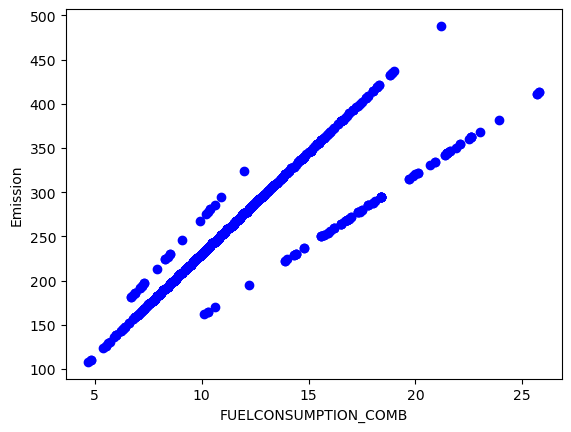

In [9]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS, color="blue")
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.show()

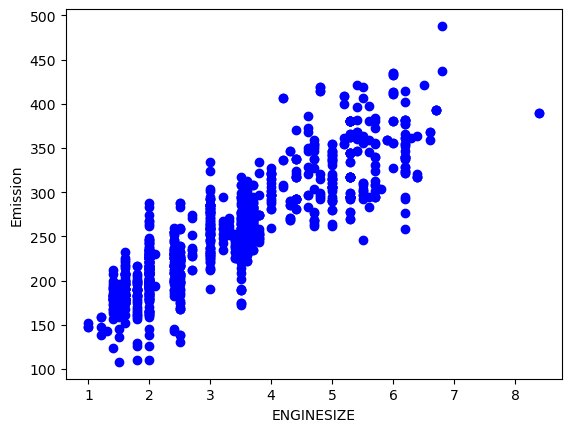

In [10]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color="blue")
plt.xlabel("ENGINESIZE")
plt.ylabel("Emission")
plt.show()

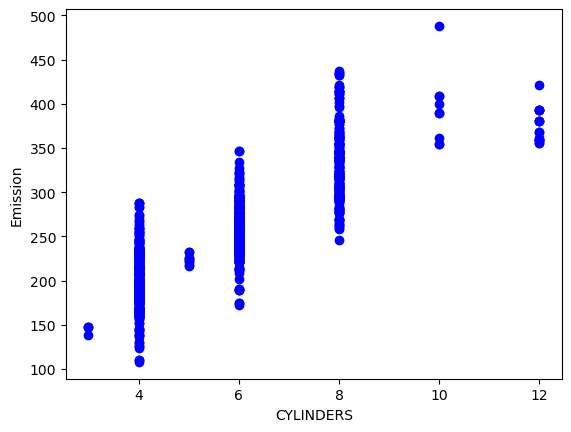

In [12]:
plt.scatter(cdf.CYLINDERS,cdf.CO2EMISSIONS, color="blue")
plt.xlabel("CYLINDERS")
plt.ylabel("Emission")
plt.show()

Now we spilt the dataset into training dataset and testing dataset, the proportion will be 80% training set and 20% testing set

In [14]:
# what this does is it randomly generates a number between 0 and 1 for each row in the dataframe,
# and then it checks if the number is less than 0.8, and then it returns a boolean value
# (True or False) for each row in the dataframe, and then it uses that boolean value to
# split the dataframe into two parts: one part for training and one part for testing.

msk = np.random.rand(len(cdf)) < 0.8
train = cdf[msk]
test = cdf[~msk]  
# ~ means not msk, so it will return the rows where msk is False, which is the test set.

Now to build the simple regression model, lets first plot the train set

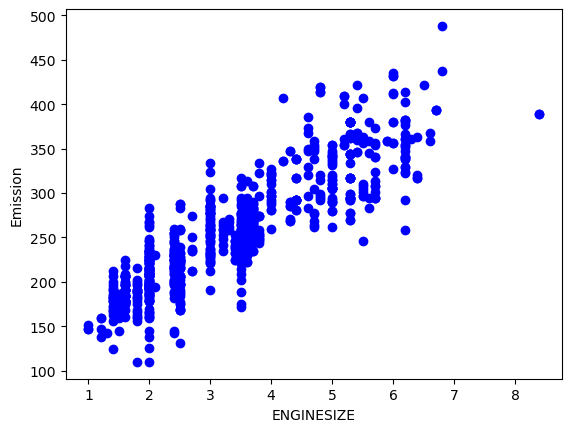

In [15]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color="blue")
plt.xlabel("ENGINESIZE")
plt.ylabel("Emission")
plt.show()

Modeling using the skitlearn package

In [ ]:
from sklearn import linear_model
reg = linear_model.LinearRegression()
# we make the data suitable for the regression model
train_x = np.asanyarray(train[["ENGINESIZE"]])
train_y = np.asanyarray(train[["CO2EMISSIONS"]])
reg.fit(train_x, train_y)

# The coefficients
print("Coefficients: ", reg.coef_) #slope
print("Intercept: ", reg.intercept_) #starting point (b)

Coefficients:  [[39.17254152]]
Intercept:  [125.09348464]


Lets plot the regression line over the scatter plot

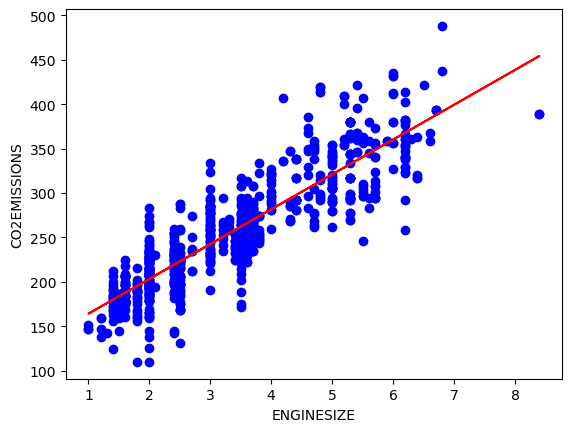

In [17]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color="blue")
# in the code below, we take the engine size and multiply it by the slope we fitted earlier, 
# and then we add the intercept to it, and then we plot it as a red line.
plt.plot(train_x, reg.coef_[0][0]*train_x + reg.intercept_[0], "-r")
plt.xlabel("ENGINESIZE")
plt.ylabel("CO2EMISSIONS")
plt.show()

Now we will evaluate the model using the following evaluation metrics

In [ ]:
from sklearn.metrics import r2_score

test_x = np.asanyarray(test[["ENGINESIZE"]])
test_y = np.asanyarray(test[["CO2EMISSIONS"]])
test_y_ = reg.predict(test_x)

print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_ - test_y))) #range of predicted outputs
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2)) #detects the outliers
print("R2-score: %.2f" % r2_score(test_y , test_y_) ) #actual model performance

Mean absolute error: 24.92
Residual sum of squares (MSE): 1084.88
R2-score: 0.74


Now lets see the evaluation metrics if we trained the model using fuel consumption

In [19]:
train_x = np.asanyarray(train[["FUELCONSUMPTION_COMB"]])
train_y = np.asanyarray(train[["CO2EMISSIONS"]])
reg.fit(train_x, train_y)

print("Coefficients: ", reg.coef_)
print("Intercept: ", reg.intercept_)

Coefficients:  [[16.41697612]]
Intercept:  [66.32790679]


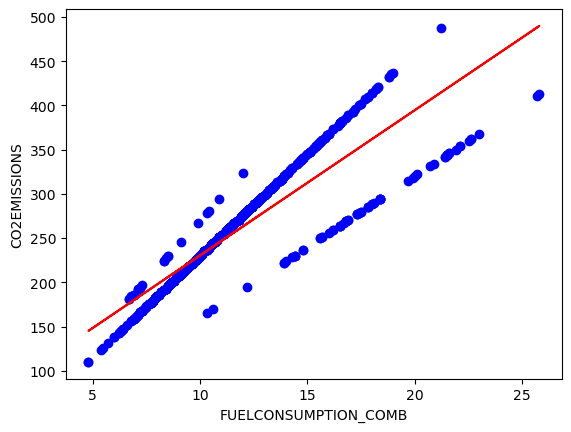

In [20]:
plt.scatter(train.FUELCONSUMPTION_COMB, train.CO2EMISSIONS, color="blue")
plt.plot(train_x, reg.coef_[0][0]*train_x + reg.intercept_[0], "-r")
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("CO2EMISSIONS")
plt.show()

Evaluating the model

In [21]:
test_x = np.asanyarray(test[["FUELCONSUMPTION_COMB"]])
test_y = np.asanyarray(test[["CO2EMISSIONS"]])
test_y_ = reg.predict(test_x)

print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_ - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y , test_y_) )

Mean absolute error: 21.22
Residual sum of squares (MSE): 895.49
R2-score: 0.79


te